最適なjpeg品質で全画像について検証

In [1]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
import os
from PIL import Image
import numpy as np
from tqdm.auto import tqdm  # これを追加

DATA_DIR = '/mnt/data1/gotou/projects/Medical/kaggledata'
TRAIN_IMG_DIR = os.path.join(DATA_DIR, 'train')
LABELS_CSV = os.path.join(DATA_DIR, 'train_labels.csv')
TEST_IMG_DIR = os.path.join(DATA_DIR, 'test')

# 出力ディレクトリ（画像・リザルト保存先）
OUTPUT_DIR = '/mnt/data1/gotou/kaggle/jpeg'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# データ拡張（学習時のみ）
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class PCamDataset(Dataset):
    def __init__(self, img_dir, labels_df, transform=None):
        self.img_dir = img_dir
        self.labels = labels_df.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        img_id = self.labels.iloc[idx, 0]
        label = self.labels.iloc[idx, 1]
        img_path = os.path.join(self.img_dir, f"{img_id}.tif")
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

labels_df = pd.read_csv(LABELS_CSV)
train_df, val_df = train_test_split(labels_df, test_size=0.1, random_state=42, stratify=labels_df['label'])

train_dataset = PCamDataset(TRAIN_IMG_DIR, train_df, train_transform)
val_dataset = PCamDataset(TRAIN_IMG_DIR, val_df, val_transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

resnet50.fc = nn.Linear(resnet50.fc.in_features, 1)
model = resnet50.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=5e-5)

In [2]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

# モデル定義（学習時と同じ）
model = models.resnet50(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 1)  # 1ユニット出力
model = model.to(device)

# 重みロード
ckpt_path = "/mnt/data1/gotou/projects/Medical/kaggledata/best_model_weights.pth"
state_dict = torch.load(ckpt_path, map_location=device)
model.load_state_dict(state_dict)
model.eval()

print(f"Loaded model from {ckpt_path}")


/home/gotou/miniconda3/envs/env/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/gotou/miniconda3/envs/env/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Loaded model from /mnt/data1/gotou/projects/Medical/kaggledata/best_model_weights.pth


In [3]:
# --- 攻撃関数 ---
import torch.nn.functional as F

mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(device)
std  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(device)

def denormalize(x, mean, std):
    # normalized -> pixel [0,1]
    return x * std + mean

def renormalize(x_pixel, mean, std):
    # pixel [0,1] -> normalized
    return (x_pixel - mean) / std

def fgsm_attack_improved(model, images, labels, epsilon_pixel, device,
                         mean_tensor=None, std_tensor=None, return_preds=True):
    """
    FGSM attack that respects per-channel normalization.
    """
    if mean_tensor is None or std_tensor is None:
        mean_tensor_local = mean
        std_tensor_local = std
    else:
        mean_tensor_local = mean_tensor
        std_tensor_local = std_tensor

    images = images.clone().detach().to(device)
    labels = labels.clone().detach().to(device)
    images.requires_grad = True

    outputs = model(images)
    if outputs.ndim > 1 and outputs.shape[1] == 1:
        outputs = outputs.squeeze(1)
    
    loss = F.binary_cross_entropy_with_logits(outputs, labels.float())
    model.zero_grad()
    loss.backward()
    grad = images.grad.data

    grad_sign = grad.sign()

    if not torch.is_tensor(epsilon_pixel):
        eps_pixel_tensor = torch.tensor(epsilon_pixel, dtype=images.dtype, device=device)
    else:
        eps_pixel_tensor = epsilon_pixel.to(device).to(images.dtype)

    if eps_pixel_tensor.ndim == 0:
        eps_norm = (eps_pixel_tensor / std_tensor_local).view(1, -1, 1, 1)
    elif eps_pixel_tensor.ndim == 1 and eps_pixel_tensor.numel() == std_tensor_local.shape[1]:
        eps_norm = (eps_pixel_tensor.view(1, -1, 1, 1) / std_tensor_local)
    else:
        eps_norm = (eps_pixel_tensor / std_tensor_local)

    adv_images = images + eps_norm * grad_sign

    adv_pixel = denormalize(adv_images, mean_tensor_local, std_tensor_local)
    adv_pixel = torch.clamp(adv_pixel, 0.0, 1.0)

    adv_images = renormalize(adv_pixel, mean_tensor_local, std_tensor_local).detach()
    adv_images.requires_grad = False

    if return_preds:
        with torch.no_grad():
            adv_out = model(adv_images)
            if adv_out.ndim > 1 and adv_out.shape[1] == 1:
                adv_out = adv_out.squeeze(1)
            adv_probs = torch.sigmoid(adv_out)
            adv_preds = (adv_probs > 0.5).long().cpu()
        del grad, grad_sign, adv_out, adv_pixel, eps_norm, eps_pixel_tensor, loss
        torch.cuda.empty_cache()
        return adv_images, adv_preds

    del grad, grad_sign, adv_pixel, eps_norm, eps_pixel_tensor, loss
    torch.cuda.empty_cache()
    return adv_images

In [4]:
# --- JPEG圧縮による防御関数 ---
import io
from PIL import Image

def jpeg_compression_defense(images, quality=75, mean_tensor=None, std_tensor=None):
    """
    JPEG圧縮による防御
    """
    if mean_tensor is None or std_tensor is None:
        mean_tensor = mean
        std_tensor = std
    
    batch_size = images.shape[0]
    defended_images = []
    
    for i in range(batch_size):
        img_pixel = denormalize(images[i:i+1], mean_tensor, std_tensor)
        img_pil = transforms.ToPILImage()(img_pixel.squeeze(0).cpu())
        
        buffer = io.BytesIO()
        img_pil.save(buffer, format='JPEG', quality=quality)
        buffer.seek(0)
        img_jpeg = Image.open(buffer).convert('RGB')
        
        img_tensor = transforms.ToTensor()(img_jpeg).unsqueeze(0).to(images.device)
        img_normalized = renormalize(img_tensor, mean_tensor, std_tensor)
        
        defended_images.append(img_normalized)
    
    return torch.cat(defended_images, dim=0)

In [6]:
# --- 検証データ全体で評価（JPEG品質11で防御） ---
import matplotlib.pyplot as plt

model.eval()

# パラメータ設定
epsilon = 8 / 255.0
jpeg_quality = 11
batch_size = 8  # メモリ節約のため小さめに

# 結果保存用
all_original_labels = []
all_original_preds = []
all_adv_preds = []
all_defended_preds = []

print(f"検証データ全体で評価中 (epsilon={epsilon:.4f}, JPEG品質={jpeg_quality})...")
print("="*60)

for batch_idx, (images, labels) in enumerate(tqdm(val_loader, desc="Evaluation")):
    images = images.to(device)
    labels = labels.to(device)
    
    # 元画像での予測
    with torch.no_grad():
        outputs = model(images)
        if outputs.ndim > 1 and outputs.shape[1] == 1:
            outputs = outputs.squeeze(1)
        probs = torch.sigmoid(outputs)
        original_preds = (probs > 0.5).long()
    
    # FGSM攻撃（ミニバッチ分割）- 勾配計算が必要なのでno_gradの外
    adv_images_list = []
    adv_preds_list = []
    for i in range(0, images.size(0), batch_size):
        img_chunk = images[i:i+batch_size]
        lbl_chunk = labels[i:i+batch_size]
        adv_chunk, adv_pred_chunk = fgsm_attack_improved(
            model=model,
            images=img_chunk,
            labels=lbl_chunk,
            epsilon_pixel=epsilon,
            device=device,
            mean_tensor=mean,
            std_tensor=std,
            return_preds=True
        )
        adv_images_list.append(adv_chunk)
        adv_preds_list.append(adv_pred_chunk)
        torch.cuda.empty_cache()
    
    adv_images = torch.cat(adv_images_list, dim=0)
    adv_preds = torch.cat(adv_preds_list, dim=0)
    
    # JPEG防御（ミニバッチ分割）
    defended_preds_list = []
    for i in range(0, adv_images.size(0), batch_size):
        adv_chunk = adv_images[i:i+batch_size]
        defended_chunk = jpeg_compression_defense(
            adv_chunk,
            quality=jpeg_quality,
            mean_tensor=mean,
            std_tensor=std
        )
        
        with torch.no_grad():
            def_outputs = model(defended_chunk)
            if def_outputs.ndim > 1 and def_outputs.shape[1] == 1:
                def_outputs = def_outputs.squeeze(1)
            def_probs = torch.sigmoid(def_outputs)
            def_preds = (def_probs > 0.5).long().cpu()
            defended_preds_list.append(def_preds)
        
        del defended_chunk, def_outputs, def_probs
        torch.cuda.empty_cache()
    
    defended_preds = torch.cat(defended_preds_list, dim=0)
    
    # 結果を保存
    all_original_labels.append(labels.cpu())
    all_original_preds.append(original_preds.cpu())
    all_adv_preds.append(adv_preds)
    all_defended_preds.append(defended_preds)
    
    del images, labels, outputs, probs, adv_images
    torch.cuda.empty_cache()

# 全結果を結合
all_original_labels = torch.cat(all_original_labels)
all_original_preds = torch.cat(all_original_preds)
all_adv_preds = torch.cat(all_adv_preds)
all_defended_preds = torch.cat(all_defended_preds)

# 精度計算
original_accuracy = (all_original_preds == all_original_labels).float().mean().item()
adv_accuracy = (all_adv_preds == all_original_labels).float().mean().item()
defended_accuracy = (all_defended_preds == all_original_labels).float().mean().item()

total_samples = len(all_original_labels)
original_correct = (all_original_preds == all_original_labels).sum().item()
adv_correct = (all_adv_preds == all_original_labels).sum().item()
defended_correct = (all_defended_preds == all_original_labels).sum().item()

print("\n" + "="*60)
print("全検証データでの評価結果")
print("="*60)
print(f"総サンプル数: {total_samples}")
print(f"Epsilon: {epsilon:.4f} (8/255)")
print(f"JPEG品質: {jpeg_quality}")
print("-"*60)
print(f"元画像の精度:        {original_correct:4d}/{total_samples} ({original_accuracy:.4f})")
print(f"敵対的画像の精度:    {adv_correct:4d}/{total_samples} ({adv_accuracy:.4f})")
print(f"JPEG防御後の精度:    {defended_correct:4d}/{total_samples} ({defended_accuracy:.4f})")
print("-"*60)
print(f"攻撃成功率:          {1 - adv_accuracy:.4f}")
print(f"防御による改善:      {defended_accuracy - adv_accuracy:.4f}")
print("="*60)

検証データ全体で評価中 (epsilon=0.0314, JPEG品質=11)...


Evaluation:   0%|          | 0/688 [00:00<?, ?it/s]


全検証データでの評価結果
総サンプル数: 22003
Epsilon: 0.0314 (8/255)
JPEG品質: 11
------------------------------------------------------------
元画像の精度:        21587/22003 (0.9811)
敵対的画像の精度:    12679/22003 (0.5762)
JPEG防御後の精度:    17268/22003 (0.7848)
------------------------------------------------------------
攻撃成功率:          0.4238
防御による改善:      0.2086


In [7]:
# --- 詳細な結果をCSVに保存 ---
results_df = pd.DataFrame({
    'Sample_ID': list(range(len(all_original_labels))),
    'True_Label': all_original_labels.numpy(),
    'Original_Pred': all_original_preds.numpy(),
    'Adversarial_Pred': all_adv_preds.numpy(),
    'Defended_Pred': all_defended_preds.numpy()
})

# 各サンプルの状態を判定
results_df['Original_Correct'] = (results_df['Original_Pred'] == results_df['True_Label']).astype(int)
results_df['Attack_Success'] = (results_df['Adversarial_Pred'] != results_df['True_Label']).astype(int)
results_df['Defense_Success'] = (
    (results_df['Attack_Success'] == 1) & 
    (results_df['Defended_Pred'] == results_df['True_Label'])
).astype(int)

csv_path = os.path.join(OUTPUT_DIR, f'jpeg_defense_all_q{jpeg_quality}.csv')
results_df.to_csv(csv_path, index=False)
print(f"\n詳細な結果をCSVに保存しました: {csv_path}")

# 追加統計
attack_success_count = results_df['Attack_Success'].sum()
defense_success_count = results_df['Defense_Success'].sum()

if attack_success_count > 0:
    recovery_rate = defense_success_count / attack_success_count
else:
    recovery_rate = 0.0

print("\n" + "="*60)
print("詳細統計")
print("="*60)
print(f"元画像で正解したサンプル数:     {results_df['Original_Correct'].sum():4d}/{total_samples}")
print(f"攻撃が成功したサンプル数:       {attack_success_count:4d}/{total_samples}")
print(f"防御が成功したサンプル数:       {defense_success_count:4d}/{attack_success_count} (回復率: {recovery_rate:.1%})")
print("="*60)


詳細な結果をCSVに保存しました: /mnt/data1/gotou/kaggle/jpeg/jpeg_defense_all_q11.csv

詳細統計
元画像で正解したサンプル数:     21587/22003
攻撃が成功したサンプル数:       9324/22003
防御が成功したサンプル数:       5170/9324 (回復率: 55.4%)


In [9]:
# --- 混同行列の計算と表示 ---
from sklearn.metrics import confusion_matrix

# 元画像、敵対的画像、防御後画像それぞれの混同行列を計算
cm_original = confusion_matrix(all_original_labels.numpy(), all_original_preds.numpy())
cm_adversarial = confusion_matrix(all_original_labels.numpy(), all_adv_preds.numpy())
cm_defended = confusion_matrix(all_original_labels.numpy(), all_defended_preds.numpy())

print("\n" + "="*60)
print("混同行列")
print("="*60)

print("\n【元画像】")
print("              予測: 0    予測: 1")
print(f"実際: 0    {cm_original[0,0]:7d}    {cm_original[0,1]:7d}")
print(f"実際: 1    {cm_original[1,0]:7d}    {cm_original[1,1]:7d}")

print("\n【敵対的画像】")
print("              予測: 0    予測: 1")
print(f"実際: 0    {cm_adversarial[0,0]:7d}    {cm_adversarial[0,1]:7d}")
print(f"実際: 1    {cm_adversarial[1,0]:7d}    {cm_adversarial[1,1]:7d}")

print(f"\n【JPEG防御後 (品質={jpeg_quality})】")
print("              予測: 0    予測: 1")
print(f"実際: 0    {cm_defended[0,0]:7d}    {cm_defended[0,1]:7d}")
print(f"実際: 1    {cm_defended[1,0]:7d}    {cm_defended[1,1]:7d}")

# 各クラスの精度（Recall）も計算
print("\n" + "-"*60)
print("各クラスの再現率 (Recall)")
print("-"*60)

def calculate_recall(cm):
    recall_0 = cm[0,0] / (cm[0,0] + cm[0,1]) if (cm[0,0] + cm[0,1]) > 0 else 0
    recall_1 = cm[1,1] / (cm[1,0] + cm[1,1]) if (cm[1,0] + cm[1,1]) > 0 else 0
    return recall_0, recall_1

recall_orig_0, recall_orig_1 = calculate_recall(cm_original)
recall_adv_0, recall_adv_1 = calculate_recall(cm_adversarial)
recall_def_0, recall_def_1 = calculate_recall(cm_defended)

print(f"\n元画像:        クラス0: {recall_orig_0:.4f}  クラス1: {recall_orig_1:.4f}")
print(f"敵対的画像:    クラス0: {recall_adv_0:.4f}  クラス1: {recall_adv_1:.4f}")
print(f"JPEG防御後:    クラス0: {recall_def_0:.4f}  クラス1: {recall_def_1:.4f}")
print("="*60)


混同行列

【元画像】
              予測: 0    予測: 1
実際: 0      12870        221
実際: 1        195       8717

【敵対的画像】
              予測: 0    予測: 1
実際: 0       8131       4960
実際: 1       4364       4548

【JPEG防御後 (品質=11)】
              予測: 0    予測: 1
実際: 0      11510       1581
実際: 1       3154       5758

------------------------------------------------------------
各クラスの再現率 (Recall)
------------------------------------------------------------

元画像:        クラス0: 0.9831  クラス1: 0.9781
敵対的画像:    クラス0: 0.6211  クラス1: 0.5103
JPEG防御後:    クラス0: 0.8792  クラス1: 0.6461



防御成功例のサンプルID: [1, 2, 3]
防御失敗例のサンプルID: [0, 5, 7]


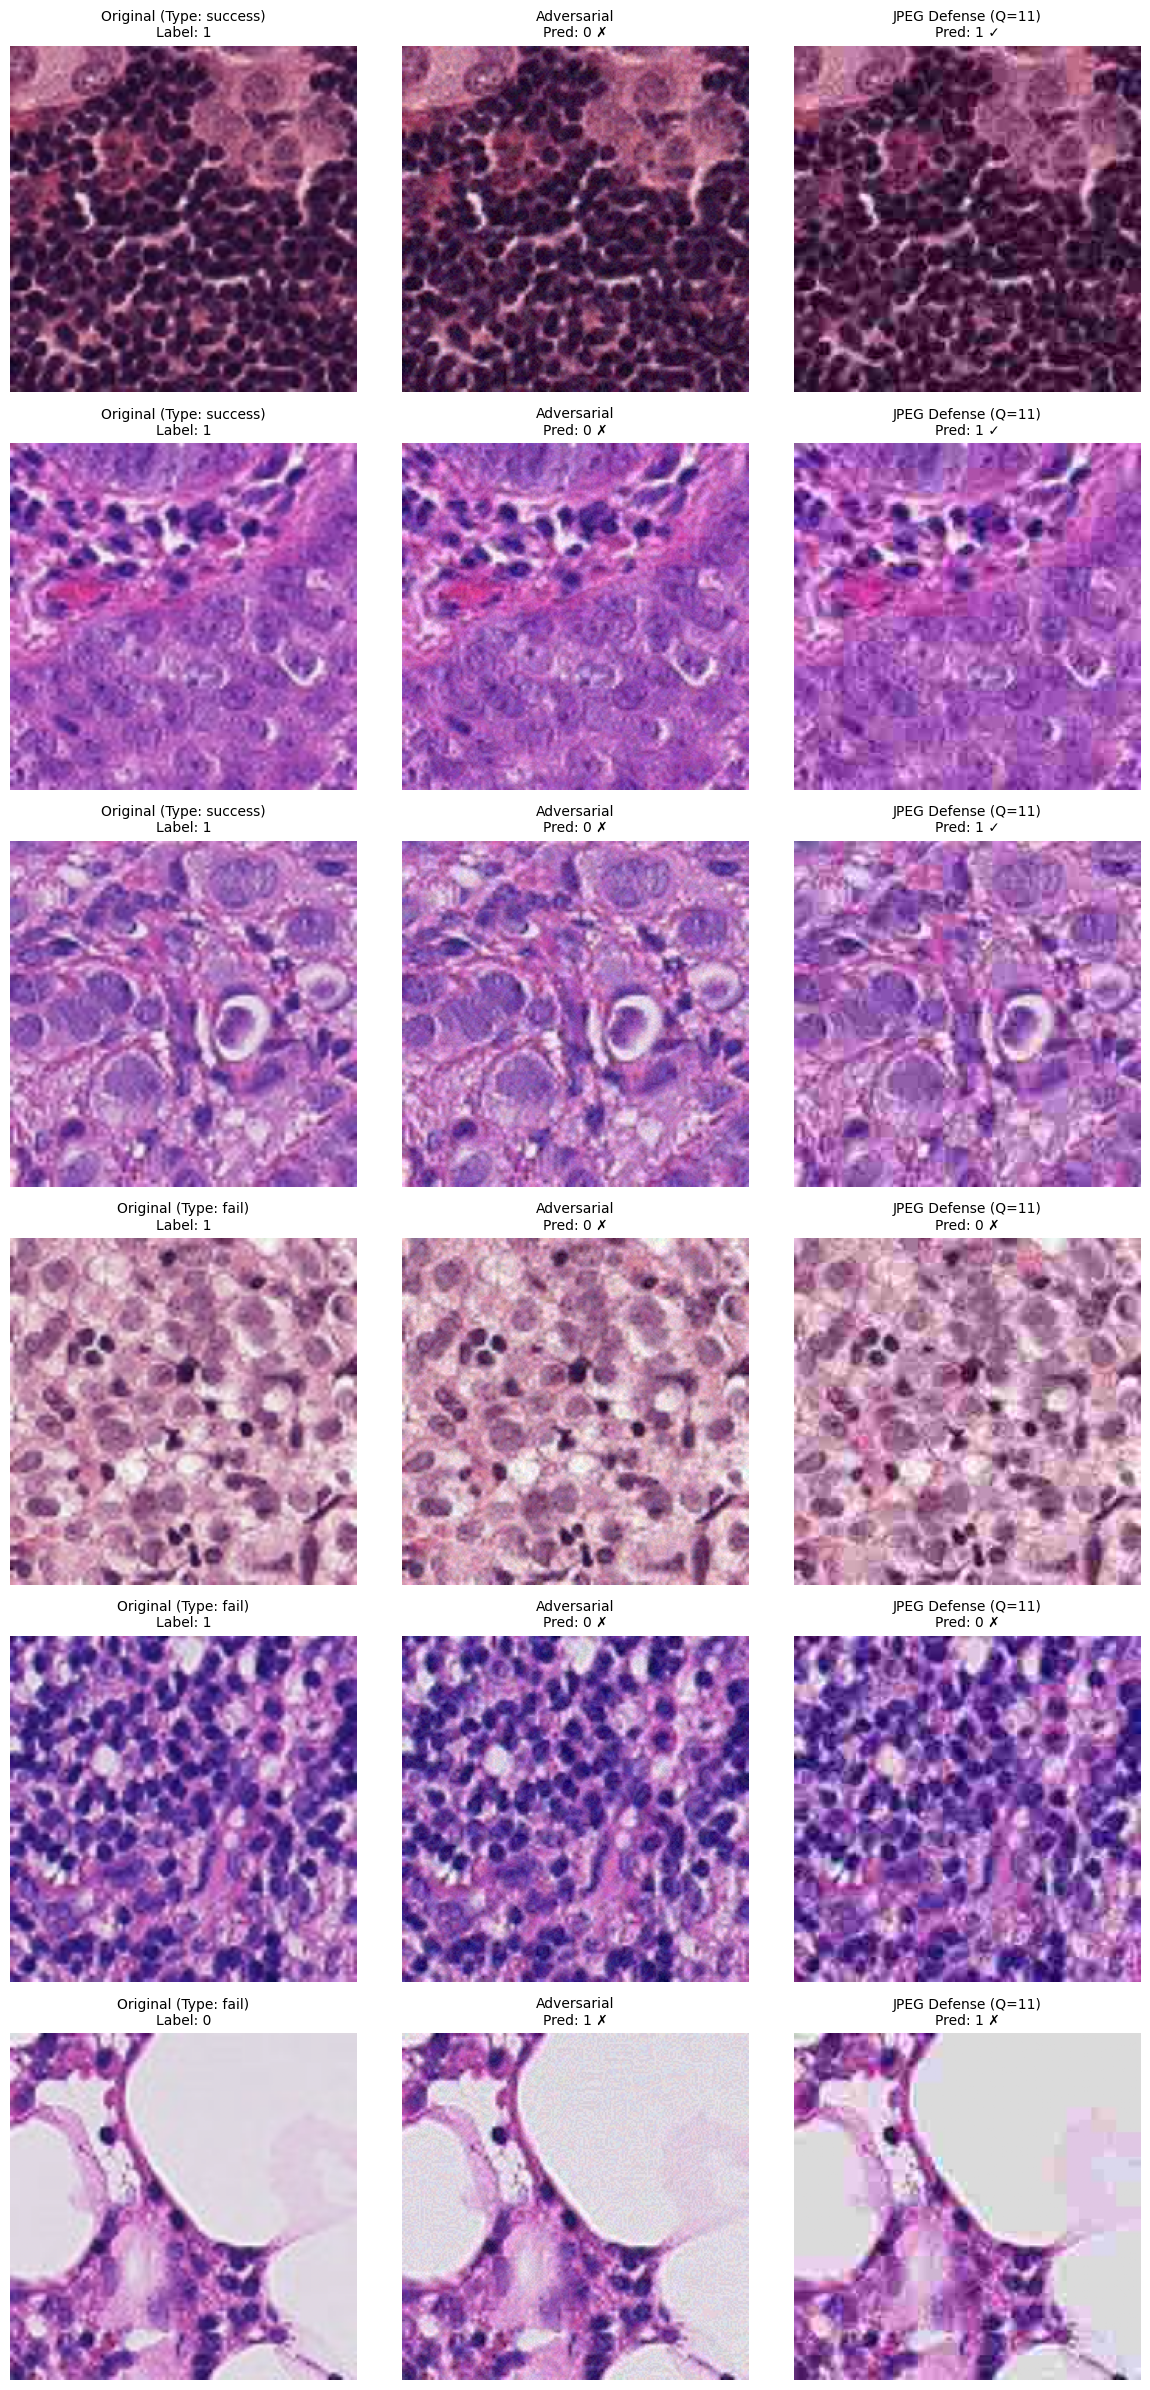


比較画像を保存しました: /mnt/data1/gotou/kaggle/jpeg/jpeg_defense_samples_q11.png


In [8]:
# --- 視覚的な比較（サンプル画像） ---
# 攻撃が成功して防御も成功したサンプル、攻撃が成功して防御も失敗したサンプルを各3枚ずつ表示

# 防御成功例を探す
defense_success_indices = results_df[results_df['Defense_Success'] == 1].head(3)['Sample_ID'].tolist()

# 防御失敗例を探す（攻撃成功したが防御失敗）
defense_fail_indices = results_df[
    (results_df['Attack_Success'] == 1) & 
    (results_df['Defense_Success'] == 0)
].head(3)['Sample_ID'].tolist()

print(f"\n防御成功例のサンプルID: {defense_success_indices}")
print(f"防御失敗例のサンプルID: {defense_fail_indices}")

# データローダーから該当画像を取得する関数
def get_sample_by_index(val_dataset, idx):
    return val_dataset[idx]

# 画像とラベルを取得
sample_images = []
sample_labels = []
sample_types = []

for idx in defense_success_indices:
    img, lbl = get_sample_by_index(val_dataset, idx)
    sample_images.append(img)
    sample_labels.append(lbl)
    sample_types.append('success')

for idx in defense_fail_indices:
    img, lbl = get_sample_by_index(val_dataset, idx)
    sample_images.append(img)
    sample_labels.append(lbl)
    sample_types.append('fail')

if len(sample_images) > 0:
    sample_images_tensor = torch.stack(sample_images).to(device)
    sample_labels_tensor = torch.tensor(sample_labels).to(device)
    
    # FGSM攻撃
    adv_samples, adv_sample_preds = fgsm_attack_improved(
        model=model,
        images=sample_images_tensor,
        labels=sample_labels_tensor,
        epsilon_pixel=epsilon,
        device=device,
        mean_tensor=mean,
        std_tensor=std,
        return_preds=True
    )
    
    # JPEG防御
    defended_samples = jpeg_compression_defense(
        adv_samples,
        quality=jpeg_quality,
        mean_tensor=mean,
        std_tensor=std
    )
    
    # 防御後の予測
    with torch.no_grad():
        def_outputs = model(defended_samples)
        if def_outputs.ndim > 1 and def_outputs.shape[1] == 1:
            def_outputs = def_outputs.squeeze(1)
        def_probs = torch.sigmoid(def_outputs)
        def_sample_preds = (def_probs > 0.5).long().cpu()
    
    # 可視化
    num_samples = len(sample_images)
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, num_samples * 4))
    
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    for i in range(num_samples):
        # 元画像
        orig_img = denormalize(sample_images_tensor[i:i+1], mean, std).squeeze(0).cpu()
        orig_img = torch.clamp(orig_img, 0, 1).permute(1, 2, 0).numpy()
        
        # 敵対的画像
        adv_img = denormalize(adv_samples[i:i+1], mean, std).squeeze(0).cpu()
        adv_img = torch.clamp(adv_img, 0, 1).permute(1, 2, 0).numpy()
        
        # 防御後の画像
        def_img = denormalize(defended_samples[i:i+1], mean, std).squeeze(0).cpu()
        def_img = torch.clamp(def_img, 0, 1).permute(1, 2, 0).numpy()
        
        true_label = sample_labels[i]
        adv_pred = adv_sample_preds[i].item()
        def_pred = def_sample_preds[i].item()
        sample_type = sample_types[i]
        
        # 表示
        axes[i, 0].imshow(orig_img)
        axes[i, 0].set_title(f'Original (Type: {sample_type})\nLabel: {true_label}', fontsize=10)
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(adv_img)
        marker = '✓' if adv_pred == true_label else '✗'
        axes[i, 1].set_title(f'Adversarial\nPred: {adv_pred} {marker}', fontsize=10)
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(def_img)
        marker = '✓' if def_pred == true_label else '✗'
        axes[i, 2].set_title(f'JPEG Defense (Q={jpeg_quality})\nPred: {def_pred} {marker}', fontsize=10)
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'jpeg_defense_samples_q{jpeg_quality}.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\n比較画像を保存しました: {os.path.join(OUTPUT_DIR, f'jpeg_defense_samples_q{jpeg_quality}.png')}")
else:
    print("\n表示するサンプルが見つかりませんでした。")